In [1]:
# Adjacency Matrix
import numpy as np

# Define the adjacency matrix
adjacency_matrix = np.array([[0, 1, 0, 0],
                             [0, 0, 1, 0],
                             [0, 1, 0, 1],
                             [1, 0, 1, 0]])

# Set the damping factor
damping_factor = 0.85

# Initialize the PageRank values
num_pages = len(adjacency_matrix)
page_rank = np.ones(num_pages) / num_pages

# Number of iterations
num_iterations = 100

for i in range(num_iterations):
    new_page_rank = np.zeros(num_pages)
    for j in range(num_pages):
        # Calculate the PageRank contribution from each linking page
        linking_pages = [k for k in range(num_pages) if adjacency_matrix[k, j] == 1]
        for linking_page in linking_pages:
            new_page_rank[j] += page_rank[linking_page] / sum(adjacency_matrix[linking_page, :])
        new_page_rank[j] = damping_factor * new_page_rank[j] + (1 - damping_factor) / num_pages
    page_rank = new_page_rank

# Print the final PageRank values
for page, rank in enumerate(page_rank):
    print(f"PR(Page {page + 1}) = {rank:.3f}")


PR(Page 1) = 0.122
PR(Page 2) = 0.302
PR(Page 3) = 0.378
PR(Page 4) = 0.198


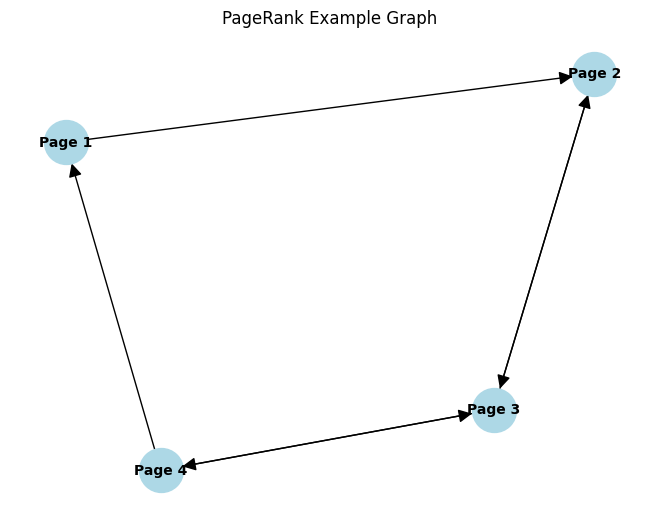

In [3]:
# Membuat Graph dari Adjacency Matrix
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Define the adjacency matrix
adjacency_matrix = np.array([[0, 1, 0, 0],
                             [0, 0, 1, 0],
                             [0, 1, 0, 1],
                             [1, 0, 1, 0]])

# Create a directed graph
G = nx.DiGraph()

# Add nodes
num_pages = len(adjacency_matrix)
G.add_nodes_from(range(num_pages))

# Add edges based on the adjacency matrix
for i in range(num_pages):
    for j in range(num_pages):
        if adjacency_matrix[i, j] == 1:
            G.add_edge(i, j)

# Draw the graph
pos = nx.spring_layout(G)  # Layout the graph
labels = {i: f"Page {i+1}" for i in range(num_pages)}
nx.draw(G, pos, with_labels=True, labels=labels, node_size=1000, node_color='lightblue',
        font_size=10, font_color='black', font_weight='bold', arrowsize=20)
plt.title("PageRank Example Graph")
plt.show()


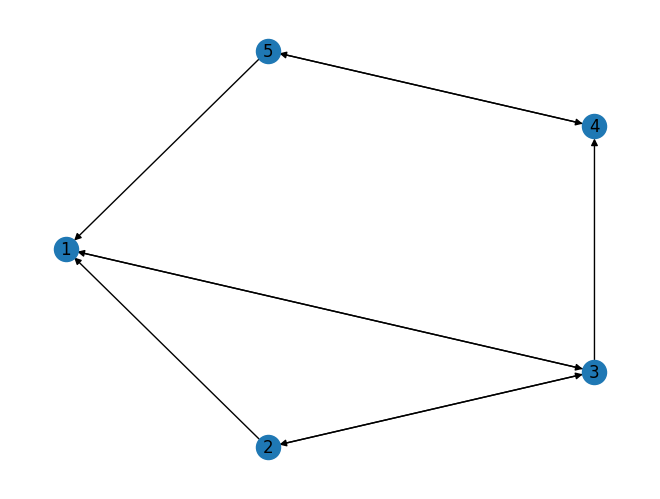

In [4]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline

myWeb = nx.DiGraph()
myPages = range(1,5)

connections = [(1,3),(2,1),(2,3),(3,1),(3,2),(3,4),(4,5),(5,1),(5,4)]
myWeb.add_nodes_from(myPages)
myWeb.add_edges_from(connections)

pos=nx.shell_layout(myWeb)
nx.draw(myWeb, pos, arrows=True, with_labels=True)
plt.show()

In [5]:
import networkx as nx
import numpy as np

def CreatePageRank(aGraph):
    nodes_set = len(aGraph)
    M = nx.to_numpy_array(aGraph)  # Menggunakan metode to_numpy_array
    outwards = np.squeeze(np.asarray(np.sum(M, axis=1)))
    prob_outwards = np.array(1.0 / outwards)
    G = np.multiply(M, prob_outwards[:, np.newaxis])

    p = np.ones(nodes_set) / float(nodes_set)
    return G, p


# Contoh penggunaan:
myWeb = nx.DiGraph()
connections = [(1, 3), (2, 1), (2, 3), (3, 1), (3, 2), (3, 4), (4, 5), (5, 1), (5, 4)]
myWeb.add_edges_from(connections)

G, p = CreatePageRank(myWeb)
print(G)


[[0.         1.         0.         0.         0.        ]
 [0.33333333 0.         0.33333333 0.33333333 0.        ]
 [0.5        0.5        0.         0.         0.        ]
 [0.         0.         0.         0.         1.        ]
 [0.5        0.         0.         0.5        0.        ]]


In [6]:
G, p = CreatePageRank(myWeb)
print(G)

[[0.         1.         0.         0.         0.        ]
 [0.33333333 0.         0.33333333 0.33333333 0.        ]
 [0.5        0.5        0.         0.         0.        ]
 [0.         0.         0.         0.         1.        ]
 [0.5        0.         0.         0.5        0.        ]]


In [7]:
import numpy as np

# Matriks adjacency (0 berarti tidak ada tautan, 1 berarti ada tautan)
adjacency_matrix = np.array([
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 1],
    [1, 0, 0, 0, 0],
    [0, 1, 0, 1, 0]
])

# Inisialisasi nilai awal PageRank
pagerank = np.array([1, 1, 1, 1, 1], dtype=float)

# Faktor damping
damping_factor = 0.85

# Jumlah iterasi
num_iterations = 100

for _ in range(num_iterations):
    # Inisialisasi PageRank baru
    new_pagerank = np.zeros(pagerank.shape, dtype=float)

    for i in range(adjacency_matrix.shape[0]):
        for j in range(adjacency_matrix.shape[1]):
            # Hitung jumlah tautan keluar dari halaman i
            num_outlinks = np.sum(adjacency_matrix[i, :])

            # Perbarui PageRank berdasarkan rumus PageRank
            if num_outlinks > 0:
                new_pagerank[j] += (damping_factor * pagerank[i] / num_outlinks)

    # Normalisasi PageRank
    new_pagerank += (1 - damping_factor) / len(pagerank)

    # Perbarui nilai PageRank
    pagerank = new_pagerank

# Hasil PageRank
print("Hasil PageRank:")
print(pagerank)


Hasil PageRank:
[1.72510772e+45 1.72510772e+45 1.72510772e+45 1.72510772e+45
 1.72510772e+45]


In [8]:
import numpy as np

# Jumlah halaman
num_pages = 5

# Vectors of outlinks
outlinks = np.array([3, 2, 1, 2, 2])

# Vectors of inlinks
inlinks = np.array([1, 2, 1, 2, 1])

# Inisialisasi nilai awal PageRank
pagerank = np.ones(num_pages, dtype=float) / num_pages

# Faktor damping
damping_factor = 0.85

# Jumlah iterasi
num_iterations = 100

for _ in range(num_iterations):
    # Inisialisasi PageRank baru
    new_pagerank = np.zeros(num_pages, dtype=float)

    for i in range(num_pages):
        for j in range(num_pages):
            if i != j and outlinks[j] > 0:
                new_pagerank[i] += damping_factor * (pagerank[j] / outlinks[j])

    # Terapkan faktor damping dan tambahkan nilai konstan
    pagerank = (1 - damping_factor) / num_pages + new_pagerank

# Hasil PageRank
print("Hasil PageRank:")
for i, pr in enumerate(pagerank):
    print(f"Halaman {chr(ord('A') + i)}: {pr:.4f}")


Hasil PageRank:
Halaman A: 379781916076663755421777920.0000
Halaman B: 356329657326501560173199360.0000
Halaman C: 300635253803169860934434816.0000
Halaman D: 356329657326501628892676096.0000
Halaman E: 356329657326501628892676096.0000


In [9]:
import numpy as np

adjacency_matrix = np.array([
    [0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0]
], dtype=float)

num_pages = adjacency_matrix.shape[0]
pagerank = np.ones(num_pages) / num_pages
damping_factor = 0.85
num_iterations = 100

for _ in range(num_iterations):
    new_pagerank = np.zeros(num_pages)
    for i in range(num_pages):
        out_links = np.sum(adjacency_matrix[i])
        if out_links > 0:
            for j in range(num_pages):
                if adjacency_matrix[i][j] == 1:
                    new_pagerank[j] += pagerank[i] / out_links
    pagerank = (1 - damping_factor) / num_pages + damping_factor * new_pagerank

print("Hasil PageRank Latihan 1:")
for i, pr in enumerate(pagerank, start=1):
    print(f"Halaman {i}: {pr:.6f}")


Hasil PageRank Latihan 1:
Halaman 1: 0.025000
Halaman 2: 0.046250
Halaman 3: 0.064313
Halaman 4: 0.079666
Halaman 5: 0.092716
Halaman 6: 0.103808


In [10]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Fungsi untuk menghitung dan menampilkan hasil PageRank
def process_and_plot(edges, title, damping=0.85):
    # Membuat directed graph dari daftar edges
    G = nx.DiGraph()
    G.add_edges_from(edges)

    # Hitung PageRank menggunakan NetworkX
    pr = nx.pagerank(G, alpha=damping)

    # Buat DataFrame agar rapi ditampilkan
    df = pd.DataFrame(sorted(pr.items()), columns=['Node', 'PageRank'])
    df['PageRank'] = df['PageRank'].round(6)

    # Gambar grafik network
    plt.figure(figsize=(5,4))
    pos = nx.spring_layout(G, seed=42)
    sizes = [max(300, 3000 * pr[n]) for n in G.nodes()]  # ukuran node sesuai nilai PR
    nx.draw(
        G, pos, with_labels=True,
        node_size=sizes,
        node_color='skyblue',
        font_weight='bold',
        arrowsize=20
    )
    plt.title(title)
    # Tampilkan nilai PageRank di bawah node
    for n, val in pr.items():
        x, y = pos[n]
        plt.text(x, y - 0.08, f"{val:.4f}", ha='center', fontsize=9)
    plt.show()

    # Kembalikan DataFrame hasil
    return df




 LATIHAN 1: 1 → 2 → 3 → 4 → 5 → 6 


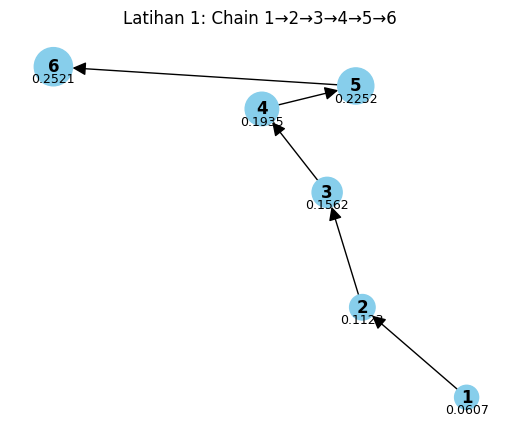

 Node  PageRank
    1  0.060716
    2  0.112324
    3  0.156192
    4  0.193480
    5  0.225174
    6  0.252114




In [11]:
edges1 = [(1,2), (2,3), (3,4), (4,5), (5,6)]  # rantai searah
print(" LATIHAN 1: 1 → 2 → 3 → 4 → 5 → 6 ")
df1 = process_and_plot(edges1, "Latihan 1: Chain 1→2→3→4→5→6")
print(df1.to_string(index=False))
print("\n" + "="*60 + "\n")

 LATIHAN 2: 1 → 2 → 3 → 4 → 5 → 1 


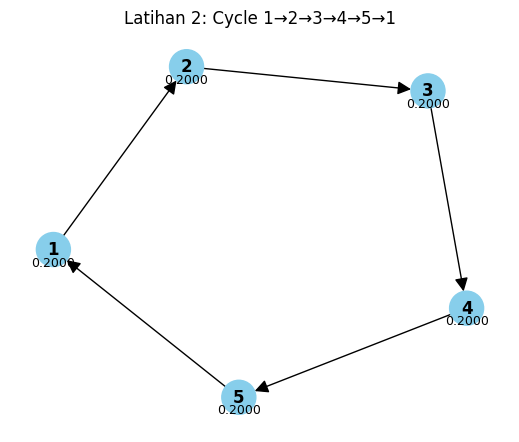

 Node  PageRank
    1       0.2
    2       0.2
    3       0.2
    4       0.2
    5       0.2




In [14]:
edges2 = [(1,2), (2,3), (3,4), (4,5), (5,1)]  # siklus
print(" LATIHAN 2: 1 → 2 → 3 → 4 → 5 → 1 ")
df2 = process_and_plot(edges2, "Latihan 2: Cycle 1→2→3→4→5→1")
print(df2.to_string(index=False))
print("\n" + "="*60 + "\n")

=== LATIHAN 3: 1 ↔ 2 ↔ 3 ↔ 4 ===


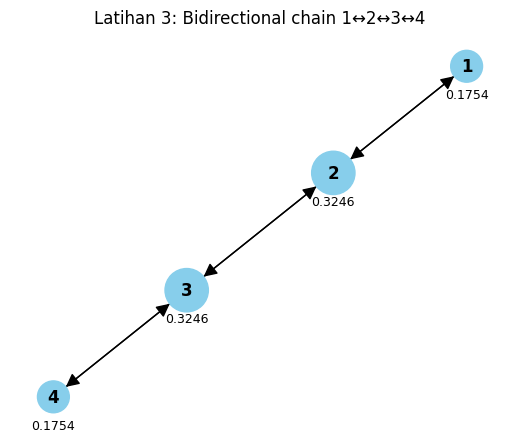

 Node  PageRank
    1  0.175438
    2  0.324562
    3  0.324562
    4  0.175438




In [15]:
edges3 = [(1,2),(2,1),(2,3),(3,2),(3,4),(4,3)]  # bolak-balik
print("=== LATIHAN 3: 1 ↔ 2 ↔ 3 ↔ 4 ===")
df3 = process_and_plot(edges3, "Latihan 3: Bidirectional chain 1↔2↔3↔4")
print(df3.to_string(index=False))
print("\n" + "="*60 + "\n")

=== LATIHAN 4: 1 → 2 → 3 → 4 → 5 → 6 → 1 ===


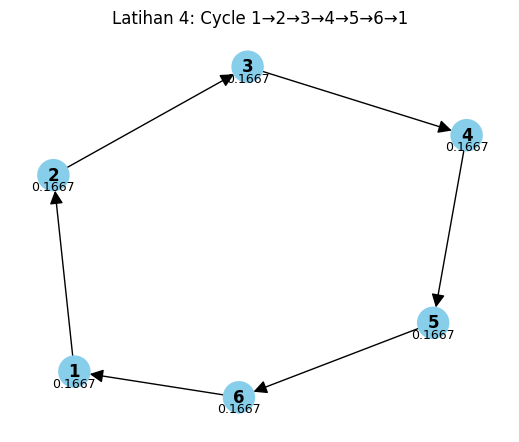

 Node  PageRank
    1  0.166667
    2  0.166667
    3  0.166667
    4  0.166667
    5  0.166667
    6  0.166667




In [16]:
edges4 = [(1,2), (2,3), (3,4), (4,5), (5,6), (6,1)]  # siklus penuh
print("=== LATIHAN 4: 1 → 2 → 3 → 4 → 5 → 6 → 1 ===")
df4 = process_and_plot(edges4, "Latihan 4: Cycle 1→2→3→4→5→6→1")
print(df4.to_string(index=False))
print("\n" + "="*60 + "\n")

=== LATIHAN 5: 1 → 2 → 3 → 4 → 1 ===


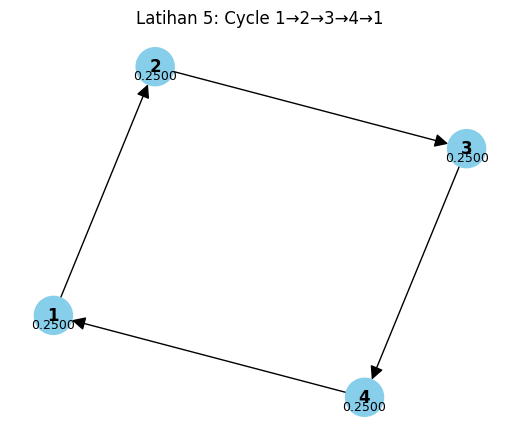

 Node  PageRank
    1      0.25
    2      0.25
    3      0.25
    4      0.25




In [17]:
edges5 = [(1,2), (2,3), (3,4), (4,1)]  # siklus 4 node
print("=== LATIHAN 5: 1 → 2 → 3 → 4 → 1 ===")
df5 = process_and_plot(edges5, "Latihan 5: Cycle 1→2→3→4→1")
print(df5.to_string(index=False))
print("\n" + "="*60 + "\n")

=== LATIHAN 6: 1→2, 2→3, 3→4, 4→1, 4→5, 5→1 ===


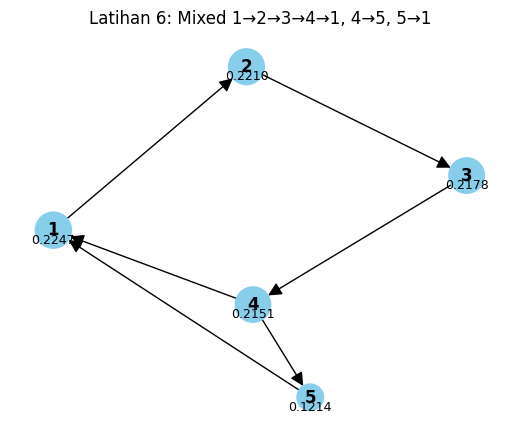

 Node  PageRank
    1  0.224654
    2  0.220956
    3  0.217813
    4  0.215142
    5  0.121435




In [18]:
edges6 = [(1,2), (2,3), (3,4), (4,1), (4,5), (5,1)]  # kombinasi arah
print("=== LATIHAN 6: 1→2, 2→3, 3→4, 4→1, 4→5, 5→1 ===")
df6 = process_and_plot(edges6, "Latihan 6: Mixed 1→2→3→4→1, 4→5, 5→1")
print(df6.to_string(index=False))
print("\n" + "="*60 + "\n")

Daftar Node: ['A', 'B', 'C', 'D', 'E']

Matriks Koneksi (Aᵀ):
[[0. 0. 0. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 0. 0. 0.]
 [0. 1. 1. 0. 0.]
 [0. 0. 1. 0. 0.]]

Matriks Stokastik (M):
[[0.  0.  0.  1.  0.5]
 [0.5 0.  0.  0.  0.5]
 [0.5 0.5 0.  0.  0. ]
 [0.  0.5 0.5 0.  0. ]
 [0.  0.  0.5 0.  0. ]]

Hasil PageRank Setelah Iterasi:
  Node  PageRank
0    A  0.257443
2    C  0.221020
3    D  0.205525
1    B  0.192096
4    E  0.123916


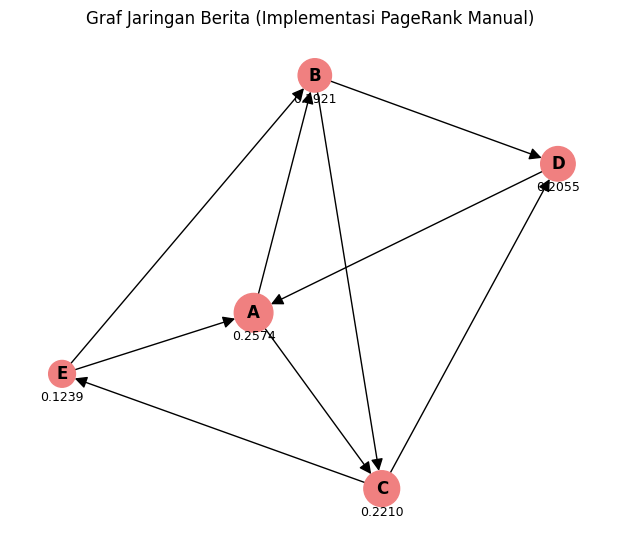


Analisis:
Algoritma PageRank dapat diterapkan dalam konteks sosial seperti
penyebaran informasi di media online. Dalam jaringan ini, setiap node
mewakili situs berita, dan edge menunjukkan tautan dari satu situs ke situs lain.

Hasil PageRank menunjukkan situs mana yang paling berpengaruh
atau paling sering dijadikan referensi oleh situs lain. Misalnya, jika
situs A dan B memiliki nilai PageRank tertinggi, berarti berita dari
situs tersebut memiliki jangkauan dan kepercayaan yang besar.

Dalam kehidupan sosial, konsep ini dapat diterapkan untuk:
- Menilai tingkat pengaruh akun media sosial (siapa yang paling banyak diikuti).
- Menentukan pusat informasi paling penting dalam komunikasi daring.
- Mengidentifikasi tokoh atau lembaga yang memiliki pengaruh besar dalam opini publik.
Dengan demikian, PageRank membantu memahami struktur kekuasaan
dan penyebaran informasi dalam masyarakat digital.



In [19]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# 1. Buat Graph (berbeda dari contoh sebelumnya)
# Misalkan: Jaringan antar website berita lokal
# A: Kompas, B: Detik, C: CNN, D: Tempo, E: Tribun
edges = [
    ("A", "B"), ("A", "C"), ("B", "C"), ("B", "D"),
    ("C", "D"), ("C", "E"), ("D", "A"), ("E", "A"), ("E", "B")
]

nodes = sorted(set(sum(([u, v] for u, v in edges), [])))
n = len(nodes)
print("Daftar Node:", nodes)

# 2. Buat Matriks Koneksi (Adjacency Matrix)
M = np.zeros((n, n))
for i, u in enumerate(nodes):
    for j, v in enumerate(nodes):
        if (nodes[j], nodes[i]) in edges:
            M[i, j] = 1

print("\nMatriks Koneksi (Aᵀ):")
print(M)

# Normalisasi kolom agar setiap kolom menjumlah 1
col_sum = M.sum(axis=0)
for j in range(n):
    if col_sum[j] != 0:
        M[:, j] /= col_sum[j]
    else:
        M[:, j] = 1 / n  # jika halaman tanpa link keluar

print("\nMatriks Stokastik (M):")
print(M)

# 3. Hitung PageRank manual
d = 0.85  # damping factor
PR = np.ones(n) / n  # inisialisasi
iters = 20           # jumlah iterasi

for i in range(iters):
    PR = (1 - d) / n + d * M.dot(PR)

# Hasil akhir
df = pd.DataFrame({
    "Node": nodes,
    "PageRank": PR.round(6)
}).sort_values(by="PageRank", ascending=False)

print("\nHasil PageRank Setelah Iterasi:")
print(df)

# 4. Gambar Graph
G = nx.DiGraph()
G.add_edges_from(edges)
plt.figure(figsize=(6,5))
pos = nx.spring_layout(G, seed=42)
sizes = [max(300, 3000 * p) for p in PR]

nx.draw(
    G, pos, with_labels=True,
    node_size=sizes,
    node_color='lightcoral',
    font_weight='bold',
    arrowsize=18
)
plt.title("Graf Jaringan Berita (Implementasi PageRank Manual)")

# Tambahkan nilai PageRank di bawah node
for n, val in zip(nodes, PR):
    x, y = pos[n]
    plt.text(x, y - 0.08, f"{val:.4f}", ha='center', fontsize=9)

plt.show()

# 5. Analisis Penerapan PageRank-
analisis = """
Analisis:
Algoritma PageRank dapat diterapkan dalam konteks sosial seperti
penyebaran informasi di media online. Dalam jaringan ini, setiap node
mewakili situs berita, dan edge menunjukkan tautan dari satu situs ke situs lain.

Hasil PageRank menunjukkan situs mana yang paling berpengaruh
atau paling sering dijadikan referensi oleh situs lain. Misalnya, jika
situs A dan B memiliki nilai PageRank tertinggi, berarti berita dari
situs tersebut memiliki jangkauan dan kepercayaan yang besar.

Dalam kehidupan sosial, konsep ini dapat diterapkan untuk:
- Menilai tingkat pengaruh akun media sosial (siapa yang paling banyak diikuti).
- Menentukan pusat informasi paling penting dalam komunikasi daring.
- Mengidentifikasi tokoh atau lembaga yang memiliki pengaruh besar dalam opini publik.
Dengan demikian, PageRank membantu memahami struktur kekuasaan
dan penyebaran informasi dalam masyarakat digital.
"""
print(analisis)
